# Evaluering av hierarkisk CNN

Kun evaluering, valg av beste epoch, tabeller og figurer.

In [1]:

from pathlib import Path
import gc, re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

tf.config.optimizer.set_jit(False)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except Exception:
        pass


2026-03-22 15:31:34.636306: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 15:31:34.664338: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 15:31:35.262688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

SEED = 42
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
EVAL_SPLIT = "val"                   # "val" eller "test"
RUN_TAG = "baseline_architecture with augmentation and dropout"    # må matche treningsskriptet

tf.random.set_seed(SEED)
np.random.seed(SEED)

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "datasplitt_preprocessed").exists():
            return p
    raise FileNotFoundError("Fant ikke prosjektrot")

PROJECT_ROOT = find_project_root(Path.cwd())
TRAIN_CSV = PROJECT_ROOT / "datasplitt_preprocessed" / "train_processed.csv"
VAL_CSV   = PROJECT_ROOT / "datasplitt_preprocessed" / "val_processed.csv"
TEST_CSV  = PROJECT_ROOT / "datasplitt_preprocessed" / "test_processed.csv"
IMG_ROOT  = PROJECT_ROOT / "datasett_preprocessed"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

PATH_COL = "processed_image" if "processed_image" in train_df.columns else "image"
for df in (train_df, val_df, test_df):
    if "w_lvl1" not in df.columns:
        df["w_lvl1"] = 1.0

num_lvl2 = int(train_df.loc[train_df["w_lvl2"] > 0, "y_lvl2"].max()) + 1
lvl2_classes = (
    train_df.loc[train_df["w_lvl2"] > 0, ["lvl2", "y_lvl2"]]
    .drop_duplicates()
    .sort_values("y_lvl2")["lvl2"]
    .astype(str)
    .tolist()
)

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_TAG:", RUN_TAG)
print("EVAL_SPLIT:", EVAL_SPLIT, "| n =", len(eval_df))


PROJECT_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions
RUN_TAG: baseline_architecture with augmentation and dropout
EVAL_SPLIT: val | n = 807


In [3]:

def decode_ready_image(path: tf.Tensor) -> tf.Tensor:
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.ensure_shape(img, [IMG_SIZE[0], IMG_SIZE[1], 3])
    return img

def build_model():
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(256, activation="relu")(x)
  

    out_lvl1 = keras.layers.Dense(1, activation="sigmoid", name="lvl1")(x)
    out_lvl2 = keras.layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

    model = keras.Model(inputs=inputs, outputs={"lvl1": out_lvl1, "lvl2": out_lvl2}, name="Modell_med_augmentering_dropout")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=6e-4),
        loss={"lvl1": keras.losses.BinaryCrossentropy(), "lvl2": keras.losses.SparseCategoricalCrossentropy()},
        metrics={"lvl1": [keras.metrics.BinaryAccuracy(name="acc")]},
        weighted_metrics={"lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")]},
        jit_compile=False,
    )
    return model

def predict_heads(model, df, batch_size=16):
    paths = [str(IMG_ROOT / p) for p in df[PATH_COL].astype(str).to_list()]
    lvl1_parts, lvl2_parts = [], []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        x = tf.stack([decode_ready_image(tf.constant(path)) for path in batch_paths], axis=0)
        preds = model(x, training=False)
        lvl1_parts.append(preds["lvl1"].numpy().reshape(-1))
        lvl2_parts.append(preds["lvl2"].numpy())
    return np.concatenate(lvl1_parts, axis=0), np.concatenate(lvl2_parts, axis=0)


In [4]:

def plot_cm_2x2(cm, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.0))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

def _lvl1_metrics_row(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    tnr = tn / (tn + fp) if (tn + fp) else np.nan
    row = {
        "lighting": name,
        "n_total": int(len(y_true)),
        "n_other": int((y_true == 0).sum()),
        "n_tesla": int((y_true == 1).sum()),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "TPR": tpr, "TNR": tnr,
        "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
        "lvl1_acc": accuracy_score(y_true, y_pred),
        "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(y_true),
    }
    return row, cm

def eval_lvl1_by_lighting(model, df, threshold=0.5, lighting_col="lighting", lighting_order=("Light", "Medium", "Dark"), batch_size=16):
    rows, cms = [], {}
    p1_all, _ = predict_heads(model, df, batch_size=batch_size)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)
    total_row, total_cm = _lvl1_metrics_row("Total", y_true_all, y_pred_all)
    rows.append(total_row); cms["Total"] = total_cm
    for light in lighting_order:
        mask = (df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue
        row, cm = _lvl1_metrics_row(light, y_true_all[mask], y_pred_all[mask])
        rows.append(row); cms[light] = cm
    return pd.DataFrame(rows), cms

def _lvl2_metrics_row(name, y_true, y_pred):
    counts = np.bincount(y_true, minlength=num_lvl2)
    maj_acc = counts.max() / len(y_true) if len(y_true) else np.nan
    row = {
        "lighting": name,
        "n_tesla": int(len(y_true)),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": maj_acc,
    }
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
    return row, cm, cm_norm

def eval_lvl2(model, df, lighting_col="lighting", lighting_order=("Light", "Medium", "Dark"), batch_size=16):
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    _, p2 = predict_heads(model, tesla_df, batch_size=batch_size)
    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2, axis=1).astype(int)

    total_row, cm, cm_norm = _lvl2_metrics_row("Total", y_true, y_pred)
    rows, cm_norm_by_light = [total_row], {"Total": cm_norm}
    for light in lighting_order:
        mask = (tesla_df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue
        row, _, cm_l_norm = _lvl2_metrics_row(light, y_true[mask], y_pred[mask])
        rows.append(row)
        cm_norm_by_light[light] = cm_l_norm

    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0)
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm.sum(axis=1)[i])))
    df_confusions = pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"]).sort_values(["rate", "support_true"], ascending=[False, False]).head(5)

    return pd.DataFrame(rows), df_per_class, df_confusions, cm_norm_by_light


## Velg beste epoch og last modellen

In [5]:

ckpt_dir = PROJECT_ROOT / "checkpoints" / RUN_TAG
ckpt_files = sorted(ckpt_dir.glob("epoch_*.weights.h5"))

rows = []
for ckpt in ckpt_files:
    tf.keras.backend.clear_session()
    gc.collect()
    tmp_model = build_model()
    tmp_model.load_weights(str(ckpt))

    df_lvl1_tmp, _ = eval_lvl1_by_lighting(tmp_model, eval_df, threshold=0.5, batch_size=BATCH_SIZE)
    lvl1_total_f1 = float(df_lvl1_tmp.loc[df_lvl1_tmp["lighting"] == "Total", "lvl1_f1_macro"].iloc[0])

    df_lvl2_tmp, _, _, _ = eval_lvl2(tmp_model, eval_df, batch_size=BATCH_SIZE)
    lvl2_total_f1 = float(df_lvl2_tmp.loc[df_lvl2_tmp["lighting"] == "Total", "lvl2_f1_macro"].iloc[0])

    epoch_num = int(re.search(r"epoch_(\d+)", ckpt.name).group(1))
    rows.append({
        "epoch": epoch_num,
        "lvl1_total_f1_macro": lvl1_total_f1,
        "lvl2_total_f1_macro": lvl2_total_f1,
        "score_50_50": 0.5 * lvl1_total_f1 + 0.5 * lvl2_total_f1,
        "checkpoint": str(ckpt),
    })
    del tmp_model
    gc.collect()

epoch_scores = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
display(epoch_scores)

best_row = epoch_scores.sort_values("score_50_50", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])
best_ckpt = best_row["checkpoint"]

tf.keras.backend.clear_session()
gc.collect()
model = build_model()
model.load_weights(best_ckpt)

print("Best epoch:", best_epoch)
print("Best checkpoint:", best_ckpt)
print("Lvl1 Total F1:", round(float(best_row["lvl1_total_f1_macro"]), 4))
print("Lvl2 Total F1:", round(float(best_row["lvl2_total_f1_macro"]), 4))
print("50/50 score:", round(float(best_row["score_50_50"]), 4))


I0000 00:00:1774189909.389717   59762 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21804 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-03-22 15:31:49.815716: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variabl

,epoch,lvl1_total_f1_macro,lvl2_total_f1_macro,score_50_50,checkpoint
0,1,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
1,2,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
2,3,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
3,4,0.365566,0.077812,0.221689,/home/andre-kidess/studier/DAT191/visual-vehic...
4,5,0.575073,0.077812,0.326442,/home/andre-kidess/studier/DAT191/visual-vehic...
...,...,...,...,...,...
245,246,0.974567,0.822231,0.898399,/home/andre-kidess/studier/DAT191/visual-vehic...
246,247,0.946952,0.806788,0.876870,/home/andre-kidess/studier/DAT191/visual-vehic...
247,248,0.963167,0.823433,0.893300,/home/andre-kidess/studier/DAT191/visual-vehic...
248,249,0.968367,0.853046,0.910707,/home/andre-kidess/studier/DAT191/visual-vehic...


Best epoch: 243
Best checkpoint: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/checkpoints/baseline_architecture with augmentation and dropout/epoch_243.weights.h5
Lvl1 Total F1: 0.9771
Lvl2 Total F1: 0.8578
50/50 score: 0.9175


/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Nivå 1-resultater

,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Total,807,465,342,458,7,11,331,0.967836,0.984946,0.976391,0.977695,0.977129,0.576208
1,Light,442,282,160,277,5,7,153,0.956250,0.982270,0.969260,0.972851,0.970531,0.638009
2,Medium,185,93,92,93,0,4,88,0.956522,1.000000,0.978261,0.978378,0.978363,0.502703
3,Dark,180,90,90,88,2,0,90,1.000000,0.977778,0.988889,0.988889,0.988888,0.500000


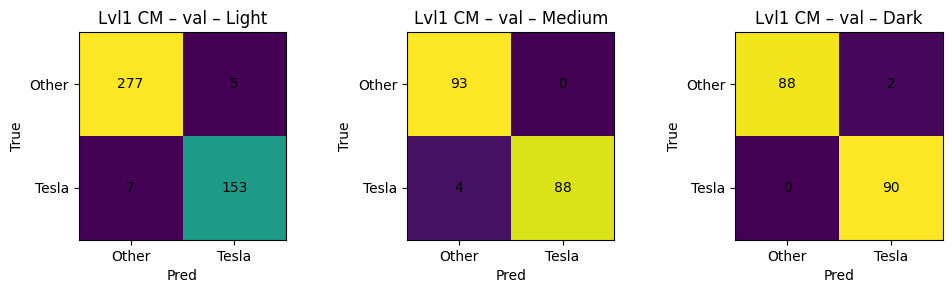

In [6]:

out_dir = PROJECT_ROOT / "results" / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5, batch_size=BATCH_SIZE)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))
for ax, light in zip(axes, ("Light", "Medium", "Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)
fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160, bbox_inches="tight")
plt.show()


## Nivå 2-resultater

,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,Total,342,0.874269,0.839771,0.857786,0.374269
1,Light,160,0.818750,0.810231,0.819997,0.362500
2,Medium,92,0.923913,0.865306,0.882865,0.380435
3,Dark,90,0.922222,0.800000,0.798510,0.388889


,class_id,class,support,precision,recall,f1
3,3,S 2016–nå,20,0.875000,0.700000,0.777778
0,0,3 2017–2023,51,0.826087,0.745098,0.783505
2,2,S 2012–2015,16,0.923077,0.750000,0.827586
4,4,X,41,0.871795,0.829268,0.850000
5,5,Y 2020–2024,128,0.861314,0.921875,0.890566
6,6,Y 2025-nå,49,0.921569,0.959184,0.940000
1,1,3 2024–nå,37,0.900000,0.972973,0.935065


,true,pred,rate,support_true
0,3 2017–2023,Y 2020–2024,0.215686,51
3,S 2016–nå,X,0.150000,20
4,X,Y 2020–2024,0.146341,41
2,S 2012–2015,Y 2025-nå,0.125000,16
6,Y 2025-nå,3 2024–nå,0.040816,49


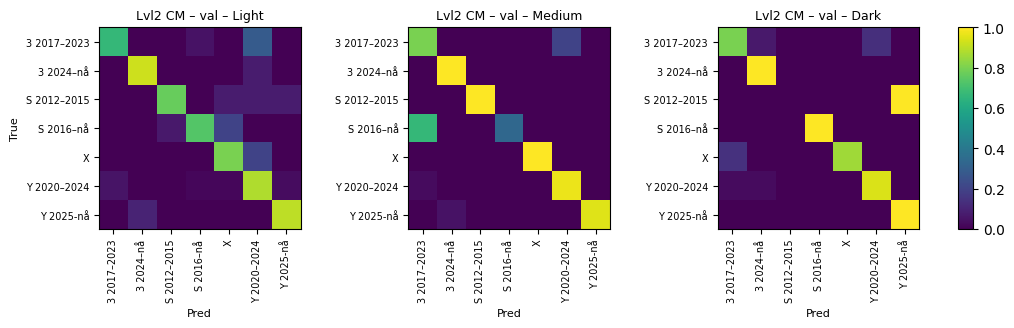

In [7]:

out_dir = PROJECT_ROOT / "results" / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_by_light, df_lvl2_per_class, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df, batch_size=BATCH_SIZE)
df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")

display(df_lvl2_by_light)
display(df_lvl2_per_class.head(10))
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))
im = None
for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue
    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)
    ax.set_xticks(range(num_lvl2)); ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2)); ax.set_yticklabels(lvl2_classes, fontsize=7)
    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)
if im is not None:
    cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
    fig.colorbar(im, cax=cax)
fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160, bbox_inches="tight")
plt.show()


,lighting,n_total,n_other,n_tesla,hier_acc,hier_bal_acc,hier_f1_macro,lvl1_tesla_precision,lvl1_tesla_recall,lvl1_other_recall,other_to_tesla_fp,tesla_to_other_fn
0,Total,807,465,342,0.928129,0.830296,0.850234,0.979290,0.967836,0.984946,7,11
1,Light,442,282,160,0.914027,0.794831,0.813574,0.968354,0.956250,0.982270,5,7
2,Medium,185,93,92,0.940541,0.767560,0.824047,1.000000,0.956522,1.000000,0,4
3,Dark,180,90,90,0.950000,0.822222,0.814818,0.978261,1.000000,0.977778,2,0


,class_id,class,support,precision,recall,f1
0,0,Other,465,0.976546,0.984946,0.980728
1,1,3 2017–2023,51,0.800000,0.705882,0.750000
2,2,3 2024–nå,37,0.871795,0.918919,0.894737
3,3,S 2012–2015,16,0.916667,0.687500,0.785714
4,4,S 2016–nå,20,0.823529,0.700000,0.756757
5,5,X,41,0.846154,0.804878,0.825000
6,6,Y 2020–2024,128,0.861314,0.921875,0.890566
7,7,Y 2025-nå,49,0.918367,0.918367,0.918367


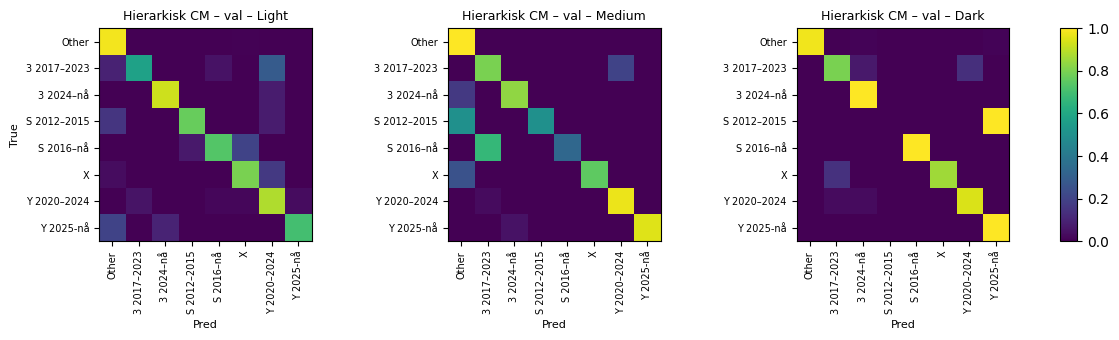

In [8]:
# ============================================================
# End-to-end hierarkisk evaluering (predicted routing)
# ============================================================

def eval_hierarchical_end_to_end(
    model,
    df,
    threshold=0.5,
    lighting_col="lighting",
    lighting_order=("Light", "Medium", "Dark"),
    batch_size=16
):
    p1_all, p2_all = predict_heads(model, df, batch_size=batch_size)

    y_true_lvl1 = df["y_lvl1"].to_numpy().astype(int)
    y_true_lvl2 = df["y_lvl2"].to_numpy().astype(int)

    # Predikert routing på nivå 1
    y_pred_lvl1 = (p1_all >= threshold).astype(int)

    # Endelig hierarkisk prediksjon som "leaf"-klasse:
    # 0 = Other
    # 1..num_lvl2 = Tesla-underklasser
    #
    # Ground truth:
    # - Other -> 0
    # - Tesla -> y_lvl2 + 1
    y_true_leaf = np.where(y_true_lvl1 == 0, 0, y_true_lvl2 + 1)

    # Prediksjon:
    # - Hvis lvl1 predikerer Other -> 0
    # - Hvis lvl1 predikerer Tesla -> argmax(lvl2) + 1
    y_pred_lvl2 = np.argmax(p2_all, axis=1).astype(int)
    y_pred_leaf = np.where(y_pred_lvl1 == 0, 0, y_pred_lvl2 + 1)

    leaf_labels = list(range(num_lvl2 + 1))
    leaf_names = ["Other"] + lvl2_classes

    def _row(name, mask):
        yt1 = y_true_lvl1[mask]
        yp1 = y_pred_lvl1[mask]
        yt_leaf = y_true_leaf[mask]
        yp_leaf = y_pred_leaf[mask]

        cm_lvl1 = confusion_matrix(yt1, yp1, labels=[0, 1])
        tn, fp, fn, tp = cm_lvl1.ravel()

        other_recall = tn / (tn + fp) if (tn + fp) else np.nan   # TNR / specificity
        tesla_recall = tp / (tp + fn) if (tp + fn) else np.nan   # TPR / sensitivity
        tesla_precision = tp / (tp + fp) if (tp + fp) else np.nan

        return {
            "lighting": name,
            "n_total": int(mask.sum()),
            "n_other": int((yt1 == 0).sum()),
            "n_tesla": int((yt1 == 1).sum()),
            "hier_acc": accuracy_score(yt_leaf, yp_leaf),
            "hier_bal_acc": balanced_accuracy_score(yt_leaf, yp_leaf),
            "hier_f1_macro": f1_score(yt_leaf, yp_leaf, average="macro", zero_division=0),
            "lvl1_tesla_precision": tesla_precision,   # branch purity
            "lvl1_tesla_recall": tesla_recall,
            "lvl1_other_recall": other_recall,
            "other_to_tesla_fp": int(fp),
            "tesla_to_other_fn": int(fn),
        }

    rows = []
    cm_leaf_by_light = {}

    mask_total = np.ones(len(df), dtype=bool)
    rows.append(_row("Total", mask_total))
    cm_leaf_by_light["Total"] = confusion_matrix(
        y_true_leaf[mask_total],
        y_pred_leaf[mask_total],
        labels=leaf_labels
    )

    for light in lighting_order:
        mask = (df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue
        rows.append(_row(light, mask))
        cm_leaf_by_light[light] = confusion_matrix(
            y_true_leaf[mask],
            y_pred_leaf[mask],
            labels=leaf_labels
        )

    df_rows = pd.DataFrame(rows)

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true_leaf, y_pred_leaf, labels=leaf_labels, zero_division=0
    )

    df_per_class = pd.DataFrame({
        "class_id": leaf_labels,
        "class": leaf_names,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    })

    return df_rows, df_per_class, cm_leaf_by_light, leaf_names


out_dir = PROJECT_ROOT / "results" / RUN_TAG / EVAL_SPLIT / "hierarchical_end_to_end"
out_dir.mkdir(parents=True, exist_ok=True)

df_hier, df_hier_per_class, cm_leaf_by_light, leaf_names = eval_hierarchical_end_to_end(
    model,
    eval_df,
    threshold=0.5,
    batch_size=BATCH_SIZE
)

df_hier.to_csv(out_dir / "hierarchical_metrics_by_lighting.csv", index=False, encoding="utf-8")
df_hier_per_class.to_csv(out_dir / "hierarchical_per_class_pr.csv", index=False, encoding="utf-8")

display(df_hier)
display(df_hier_per_class)

# ------------------------------------------------------------
# Leaf confusion matrices per lighting
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
im = None

for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_leaf_by_light:
        ax.axis("off")
        continue

    cm = cm_leaf_by_light[light]
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    im = ax.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Hierarkisk CM – {EVAL_SPLIT} – {light}", fontsize=9)
    ax.set_xticks(range(len(leaf_names)))
    ax.set_xticklabels(leaf_names, rotation=90, fontsize=7)
    ax.set_yticks(range(len(leaf_names)))
    ax.set_yticklabels(leaf_names, fontsize=7)
    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)
if im is not None:
    cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
    fig.colorbar(im, cax=cax)

fig.savefig(out_dir / "cm_hierarchical_norm_by_lighting.png", dpi=160, bbox_inches="tight")
plt.show()

Other -> Tesla: 7
Tesla -> Other: 11


,processed_image,y_lvl1,y_pred_lvl1,p_tesla_lvl1,y_pred_lvl2,pred_lvl2_name,lighting,lvl2,y_lvl2
308,val/Eksternt/non-tesla/daylight/0660_01663.jpg,0,1,1.000000,5,Y 2020–2024,Light,NaN,0
205,val/Egenprodusert/non-tesla/dark/IMG_4817.jpg,0,1,0.999996,1,3 2024–nå,Dark,NaN,0
199,val/Egenprodusert/non-tesla/daylight/%~n1-493.jpg,0,1,0.999617,4,X,Light,NaN,0
39,val/Eksternt/non-tesla/daylight/1557_07278.jpg,0,1,0.988002,3,S 2016–nå,Light,NaN,0
609,val/Egenprodusert/non-tesla/dark/IMG_4392.jpg,0,1,0.840421,6,Y 2025-nå,Dark,NaN,0
519,val/Eksternt/non-tesla/daylight/1049_01931.jpg,0,1,0.729086,0,3 2017–2023,Light,NaN,0
260,val/Eksternt/non-tesla/daylight/0857_05206.jpg,0,1,0.581689,4,X,Light,NaN,0


,processed_image,y_lvl1,y_pred_lvl1,p_tesla_lvl1,y_pred_lvl2,pred_lvl2_name,lighting,lvl2,y_lvl2
72,val/Eksternt/Tesla/daylight/Stanford/015244.jpg,1,0,0.000003,4,X,Light,S 2012–2015,2
430,val/Eksternt/Tesla/daylight/Stanford/015218.jpg,1,0,0.000012,6,Y 2025-nå,Light,S 2012–2015,2
737,val/Egenprodusert/Tesla/daylight/20260129_1217...,1,0,0.028291,6,Y 2025-nå,Light,Y 2025-nå,6
124,val/Eksternt/Tesla/daylight/Kaggle/X/t41.jpg,1,0,0.036997,5,Y 2020–2024,Light,X,4
163,val/Egenprodusert/Tesla/low-light/IMG_1312.jpg,1,0,0.082378,2,S 2012–2015,Medium,S 2012–2015,2
503,val/Egenprodusert/Tesla/low-light/IMG_1590.jpg,1,0,0.084855,1,3 2024–nå,Medium,3 2024–nå,1
481,val/Egenprodusert/Tesla/low-light/%~n1-62.jpg,1,0,0.088580,4,X,Medium,X,4
4,val/Eksternt/Tesla/daylight/Kaggle/3/images - ...,1,0,0.110548,0,3 2017–2023,Light,3 2017–2023,0
244,val/Egenprodusert/Tesla/daylight/%~n1-534.jpg,1,0,0.133785,0,3 2017–2023,Light,3 2017–2023,0
132,val/Egenprodusert/Tesla/low-light/IMG_1597.jpg,1,0,0.442700,1,3 2024–nå,Medium,3 2024–nå,1


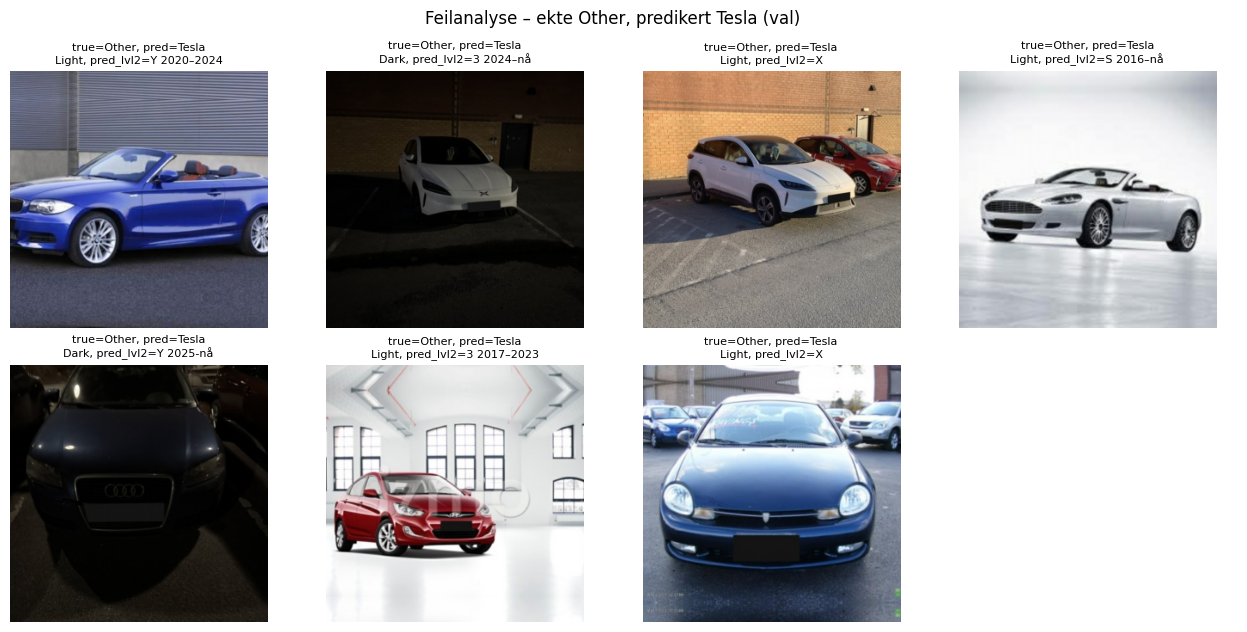

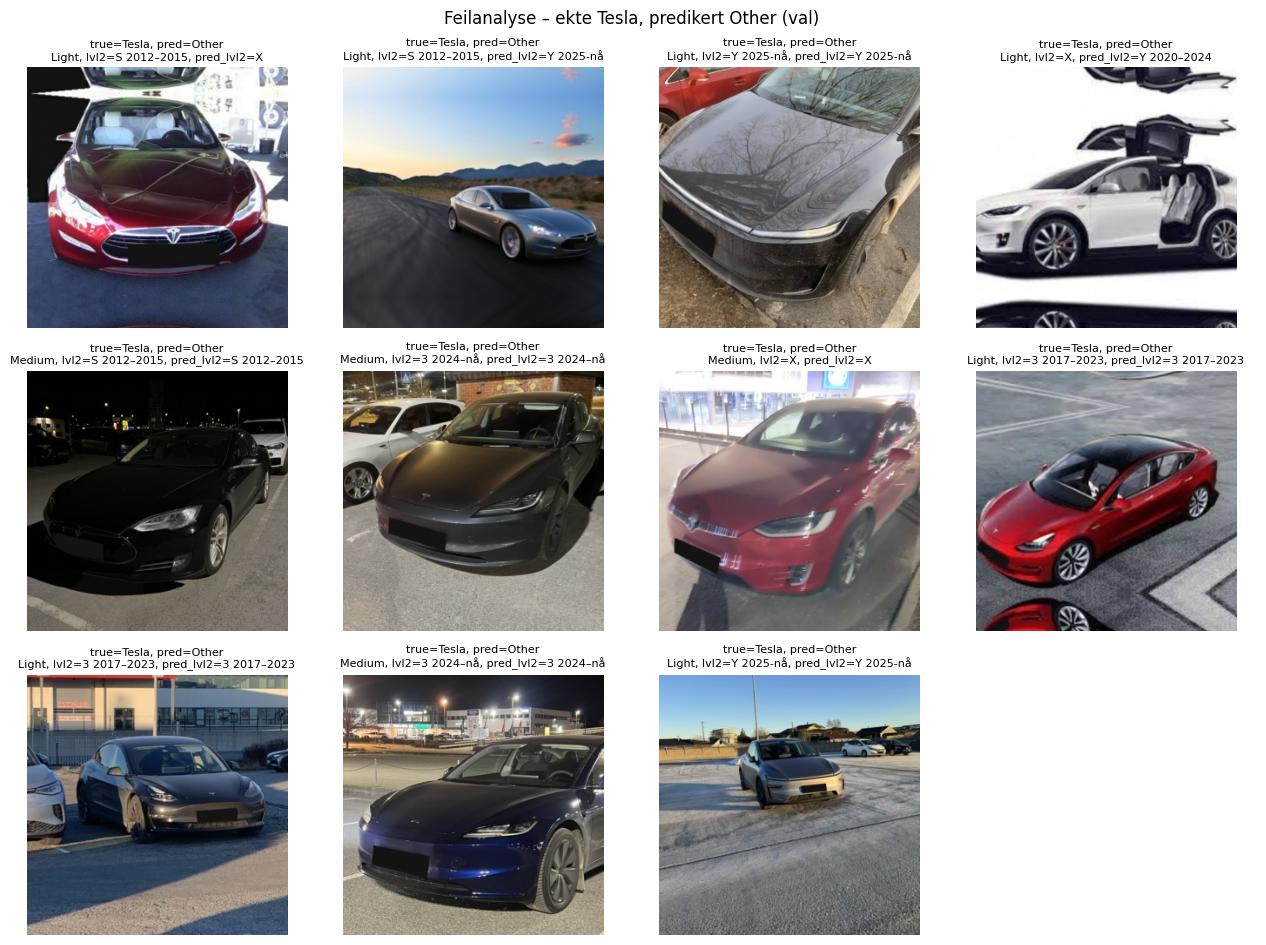

In [10]:
# ============================================================
# Feilanalyse: vis bilder som feiles på nivå 1
#   1) Other -> Tesla
#   2) Tesla -> Other
# ============================================================

from math import ceil
from PIL import Image

def show_image_grid(df_subset, title, max_images=24, cols=4, figsize_per_tile=(3.2, 3.2)):
    n = min(len(df_subset), max_images)
    if n == 0:
        print(f"{title}: Ingen bilder å vise.")
        return

    df_show = df_subset.head(n).copy()
    rows = ceil(n / cols)
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(cols * figsize_per_tile[0], rows * figsize_per_tile[1])
    )

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[ax] for ax in axes])

    axes_flat = axes.flatten()

    for ax in axes_flat[n:]:
        ax.axis("off")

    for ax, (_, row) in zip(axes_flat[:n], df_show.iterrows()):
        img_path = IMG_ROOT / str(row[PATH_COL])
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Kunne ikke lese bilde\n{img_path.name}\n{e}",
                    ha="center", va="center", fontsize=8)
        ax.axis("off")

        true_lbl = "Tesla" if int(row["y_lvl1"]) == 1 else "Other"
        pred_lbl = "Tesla" if int(row["y_pred_lvl1"]) == 1 else "Other"

        extra = []
        if "lighting" in row:
            extra.append(str(row["lighting"]))
        if "lvl2" in row and pd.notna(row["lvl2"]):
            extra.append(f"lvl2={row['lvl2']}")
        if "pred_lvl2_name" in row and pd.notna(row["pred_lvl2_name"]):
            extra.append(f"pred_lvl2={row['pred_lvl2_name']}")

        subtitle = "\n".join([
            f"true={true_lbl}, pred={pred_lbl}",
            ", ".join(extra) if extra else ""
        ]).strip()

        ax.set_title(subtitle, fontsize=8)

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


def build_lvl1_error_analysis_df(model, df, threshold=0.5, batch_size=16):
    p1_all, p2_all = predict_heads(model, df, batch_size=batch_size)

    out = df.copy().reset_index(drop=True)
    out["p_tesla_lvl1"] = p1_all
    out["y_pred_lvl1"] = (p1_all >= threshold).astype(int)

    pred_lvl2_idx = np.argmax(p2_all, axis=1).astype(int)
    out["y_pred_lvl2"] = pred_lvl2_idx
    out["pred_lvl2_name"] = [lvl2_classes[i] for i in pred_lvl2_idx]

    return out


# Bygg analyse-df med prediksjoner
df_err = build_lvl1_error_analysis_df(
    model,
    eval_df,
    threshold=0.5,
    batch_size=BATCH_SIZE
)

# Feiltype 1: Other -> Tesla
df_other_to_tesla = df_err[
    (df_err["y_lvl1"].astype(int) == 0) &
    (df_err["y_pred_lvl1"].astype(int) == 1)
].copy().sort_values("p_tesla_lvl1", ascending=False)

# Feiltype 2: Tesla -> Other
df_tesla_to_other = df_err[
    (df_err["y_lvl1"].astype(int) == 1) &
    (df_err["y_pred_lvl1"].astype(int) == 0)
].copy().sort_values("p_tesla_lvl1", ascending=True)

print("Other -> Tesla:", len(df_other_to_tesla))
print("Tesla -> Other:", len(df_tesla_to_other))

# Lagre tabeller for senere analyse
out_dir = PROJECT_ROOT / "results" / RUN_TAG / EVAL_SPLIT / "error_analysis"
out_dir.mkdir(parents=True, exist_ok=True)

cols_to_save = [
    PATH_COL, "y_lvl1", "y_pred_lvl1", "p_tesla_lvl1",
    "y_pred_lvl2", "pred_lvl2_name"
]
for c in ["lighting", "lvl2", "y_lvl2"]:
    if c in df_err.columns and c not in cols_to_save:
        cols_to_save.append(c)

df_other_to_tesla[cols_to_save].to_csv(
    out_dir / "other_predicted_as_tesla.csv",
    index=False,
    encoding="utf-8"
)

df_tesla_to_other[cols_to_save].to_csv(
    out_dir / "tesla_predicted_as_other.csv",
    index=False,
    encoding="utf-8"
)

display(df_other_to_tesla[cols_to_save].head(20))
display(df_tesla_to_other[cols_to_save].head(20))

# Vis bilder
show_image_grid(
    df_other_to_tesla,
    title=f"Feilanalyse – ekte Other, predikert Tesla ({EVAL_SPLIT})",
    max_images=24,
    cols=4
)

show_image_grid(
    df_tesla_to_other,
    title=f"Feilanalyse – ekte Tesla, predikert Other ({EVAL_SPLIT})",
    max_images=24,
    cols=4
)